In [39]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np
from pathlib import Path
import re
from datetime import datetime
import string
# 

In [40]:
sys.path.append('Utils/')
from PlotUtils import (setMplParam, 
                       getColour, 
                       getHatch, 
                       getHistoParam, 
                       enable_histogram_counts)
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
# from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor

In [41]:
base = Path("/home/cyan_white_tower/projects/MeteoFormer/test_results")

TEST_RESIDUAL_PATTERN = re.compile(
    r"(?P<ckpt_tag>(?:epoch-\d+-val_loss-[0-9.]+|last))"
    r"_test_residuals\.(?P<extension>csv|csv\.gz|parquet)$"
)

runs_vanilla = {
    # "vanila_none_basic": base / "20260522" / "114331", 
    # "vanila_abs_basic": base / "20260522" / "120735",
    "vanila_sin_basic": base / "20260522" / "160504", # nice
    # "vanila_none_t5": base / "20260522" / "162154",
    "vanila_sin_t5": base / "20260522" / "163607", # nice
    # "vanila_none_alibi": base / "20260522" / "165229",
    "vanila_sin_alibi": base / "20260522" / "171146", # nice
    # "vanila_none_rope": base / "20260522" / "172607",
    "vanila_sin_rope": base / "20260522" / "174029", # nice
}

In [42]:
runs_informer = {
    # "inform_non_basic": base / "20260522" / "204637",
    # "inform_sin_basic": base / "20260522" / "220303", # nice
    # "inform_non_t5": base / "20260522" / "222203",
    # "inform_non_ali": base / "20260522" / "223014",
    # "inform_non_rope": base / "20260522" / "223712",
    # "inform_non_probspa": base / "20260522" / "224453",
    # "inform_sin_probspa": base / "20260522" / "225230", # nice
    "inform_sin_basic (distil)": base / "20260522" / "225230", # nice
    "inform_sin_probspa(1e-4) (no distil)": base / "20260523" / "154205", # max lr 1e-4
    "inform_sin_probspa(3e-5) (no distil)": base / "20260523" / "155524", # max lr 3e-5
    "inform_sin_probspa(3e-5) (distil)": base / "20260523" / "161459", # max lr 3e-5
    "inform_sin_probspa(3e-5, 1e3) (distil)": base / "20260523" / "170812", # max lr 3e-5
    
}

In [43]:
def parse_test_residual_filename(
    file_path: str | Path,
    base: Path,
) -> dict:
    file_path = Path(file_path)

    match = TEST_RESIDUAL_PATTERN.match(file_path.name)
    if not match:
        raise ValueError(
            f"Filename does not match expected test residual pattern: {file_path.name}"
        )

    info = match.groupdict()

    relative_path = file_path.relative_to(base)

    # Expected structure:
    # test_results/{run_date}/{run_time}/{filename}
    info["run_date"] = relative_path.parts[0]
    info["run_time"] = relative_path.parts[1]

    info["path"] = file_path
    info["relative_path"] = relative_path

    info["run_datetime"] = datetime.strptime(
        info["run_date"] + info["run_time"],
        "%Y%m%d%H%M%S",
    )

    ckpt_tag = info["ckpt_tag"]

    if ckpt_tag == "last":
        info["checkpoint_type"] = "last"
        info["epoch"] = None
        info["val_loss"] = None
    else:
        info["checkpoint_type"] = "epoch"

        epoch_match = re.search(r"epoch-(\d+)", ckpt_tag)
        val_loss_match = re.search(r"val_loss-([0-9.]+)", ckpt_tag)

        info["epoch"] = int(epoch_match.group(1)) if epoch_match else None
        info["val_loss"] = float(val_loss_match.group(1)) if val_loss_match else None

    return info

In [44]:
def select_best_residual_file(
    files: list[Path],
    base: Path,
) -> Path:
    """
    Select the residual file with the lowest validation loss.

    Files with val_loss=None, e.g. 'last', are ignored unless no epoch files exist.
    """
    parsed = []

    for file_path in files:
        info = parse_test_residual_filename(file_path, base=base)
        parsed.append((file_path, info))

    # Prefer files with actual validation loss
    epoch_files = [
        (file_path, info)
        for file_path, info in parsed
        if info["val_loss"] is not None
    ]

    if epoch_files:
        best_file, best_info = min(
            epoch_files,
            key=lambda item: item[1]["val_loss"],
        )
        return best_file

    # Fallback: if only "last" exists
    return parsed[0][0]

In [45]:
def find_test_residual_files(run_dir: str | Path) -> list[Path]:
    run_dir = Path(run_dir)

    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory does not exist: {run_dir}")

    files = []
    files.extend(run_dir.glob("*_test_residuals.parquet"))
    files.extend(run_dir.glob("*_test_residuals.csv"))
    files.extend(run_dir.glob("*_test_residuals.csv.gz"))

    files = sorted(files)

    if not files:
        raise FileNotFoundError(f"No residual files found in: {run_dir}")

    return files

In [46]:
def read_residual_file(file_path: str | Path) -> pd.DataFrame:
    file_path = Path(file_path)

    if file_path.suffix == ".parquet":
        return pd.read_parquet(file_path)

    if file_path.name.endswith(".csv.gz"):
        return pd.read_csv(file_path, compression="gzip")

    if file_path.suffix == ".csv":
        return pd.read_csv(file_path)

    raise ValueError(f"Unsupported file type: {file_path}")

In [47]:
def load_test_residuals_from_runs(
    runs: dict[str, Path],
    base: Path,
    best_only: bool = True,
) -> pd.DataFrame:
    all_dfs = []
    group_counter = 0

    for run_label, run_dir in runs.items():
        files = find_test_residual_files(run_dir)

        if best_only:
            files = [select_best_residual_file(files, base=base)]

        for file_path in files:
            info = parse_test_residual_filename(file_path, base=base)
            df = read_residual_file(file_path)

            group_id = string.ascii_uppercase[group_counter]

            df["group_id"] = group_id
            df["run_label"] = run_label
            df["run_date"] = info["run_date"]
            df["run_time"] = info["run_time"]
            df["ckpt_tag"] = info["ckpt_tag"]
            df["epoch"] = info["epoch"]
            df["val_loss"] = info["val_loss"]
            df["source_file"] = str(file_path)

            all_dfs.append(df)
            group_counter += 1

    if not all_dfs:
        raise ValueError("No residual data loaded.")

    return pd.concat(all_dfs, ignore_index=True)

In [48]:
def make_plot_label(run_label: str, ckpt_tag: str, epoch, val_loss) -> str:
    if epoch is not None and val_loss is not None:
        return f"{run_label} | epoch {epoch} | val_loss={val_loss:.4f}"
    return f"{run_label} | {ckpt_tag}"

In [49]:
def plot_all_residual_distribution(
    df_all: pd.DataFrame):
    
    def make_hist_stat_dict(group_id: str, x: pd.Series) -> dict:
        return {
            f"N {group_id}": len(x),
            f"mean {group_id}": x.mean(),
            f"median {group_id}": x.median(),
            f"std {group_id}": x.std(),
        }
    fig, ax = plt.subplots(figsize=(13, 11))

    grouped = df_all.groupby(
        ["group_id", "run_label", "ckpt_tag", "epoch", "val_loss"],
        dropna=False,
    )
    
    stat_blocks = []

    for i, ((group_id, run_label, ckpt_tag, epoch, val_loss), df_group) in enumerate(grouped):
        x = df_group["residual"].dropna()

        label = f"{group_id}: {make_plot_label(run_label, ckpt_tag, epoch, val_loss)}"

        Nbins, binwidth, bins, counts, bin_centers  = getHistoParam(x, binwidth=0.333)
        # enable_histogram_counts(fontsize=10, rotation=90, min_count=5, every=3)
        label = f"{group_id}: {make_plot_label(run_label, ckpt_tag, epoch, val_loss)}"
        
        ax.hist(
            x,
            bins=bins,
            histtype="step",
            label=label,
            linewidth=1,
            hatch=getHatch(i),
        )
        d = make_hist_stat_dict(group_id, x)
        stat_blocks.append(nice_string_output(d, decimals=3))

    ax.set_xlabel("Residuals")
    ax.set_ylabel("Counts")
    ax.set_title("Test residual distribution")
    ax.legend(fontsize=12, loc="upper right")
    ax.set_ylim(0,14000)
    
    split_idx = 8

    stat_text_left = "\n\n".join(stat_blocks[:split_idx])
    stat_text_right = "\n\n".join(stat_blocks[split_idx:])

    add_text_to_ax(
        0.02,
        0.98,
        stat_text_left,
        ax,
        fontsize=12,
    )
    
    if len(stat_blocks) > split_idx:
        add_text_to_ax(
            0.72,
            0.60,
            stat_text_right,
            ax,
            fontsize=12,
        )

In [50]:
df_vanilla = load_test_residuals_from_runs(runs_vanilla, base=base)
df_informer = load_test_residuals_from_runs(runs_informer, base=base)

In [51]:
# df_all.columns

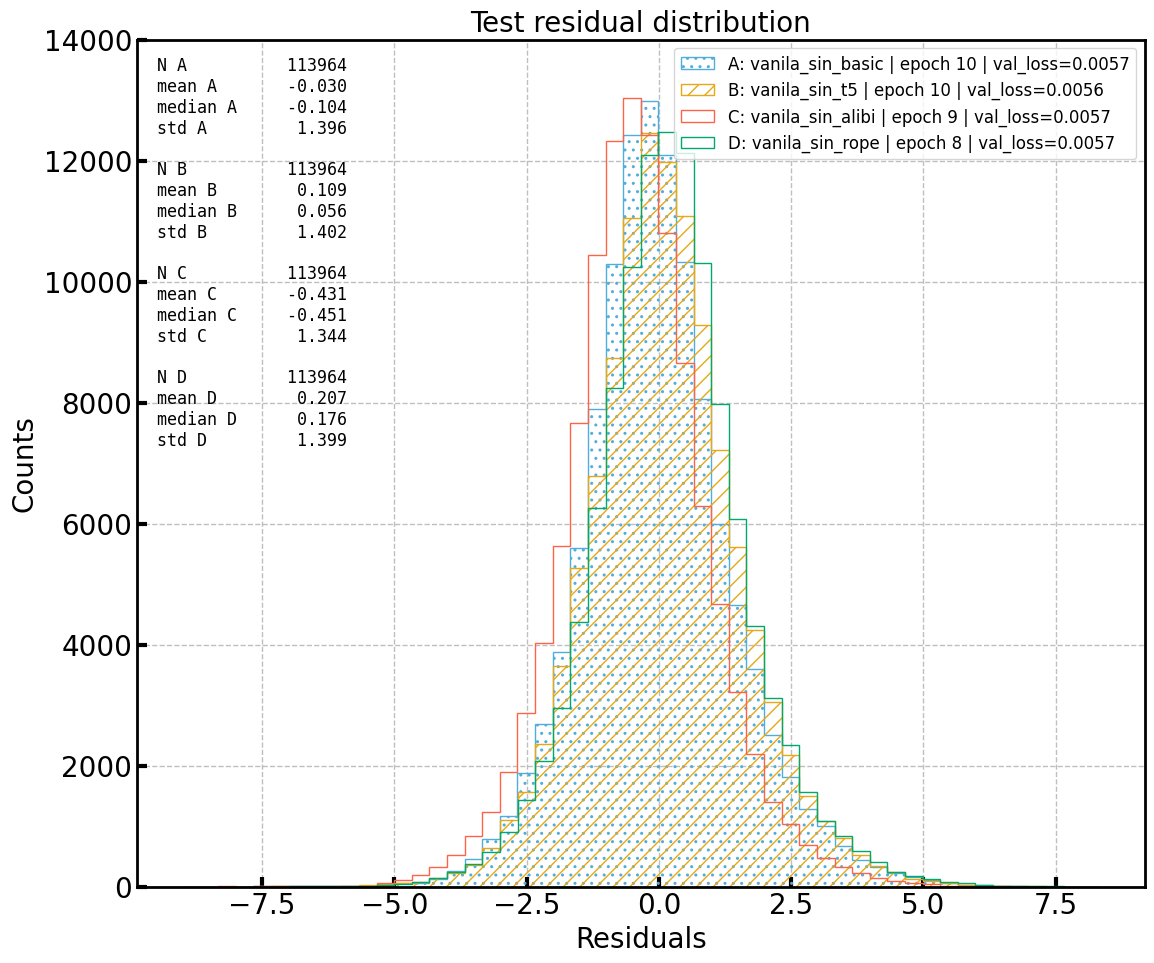

In [52]:
plot_all_residual_distribution(df_vanilla)

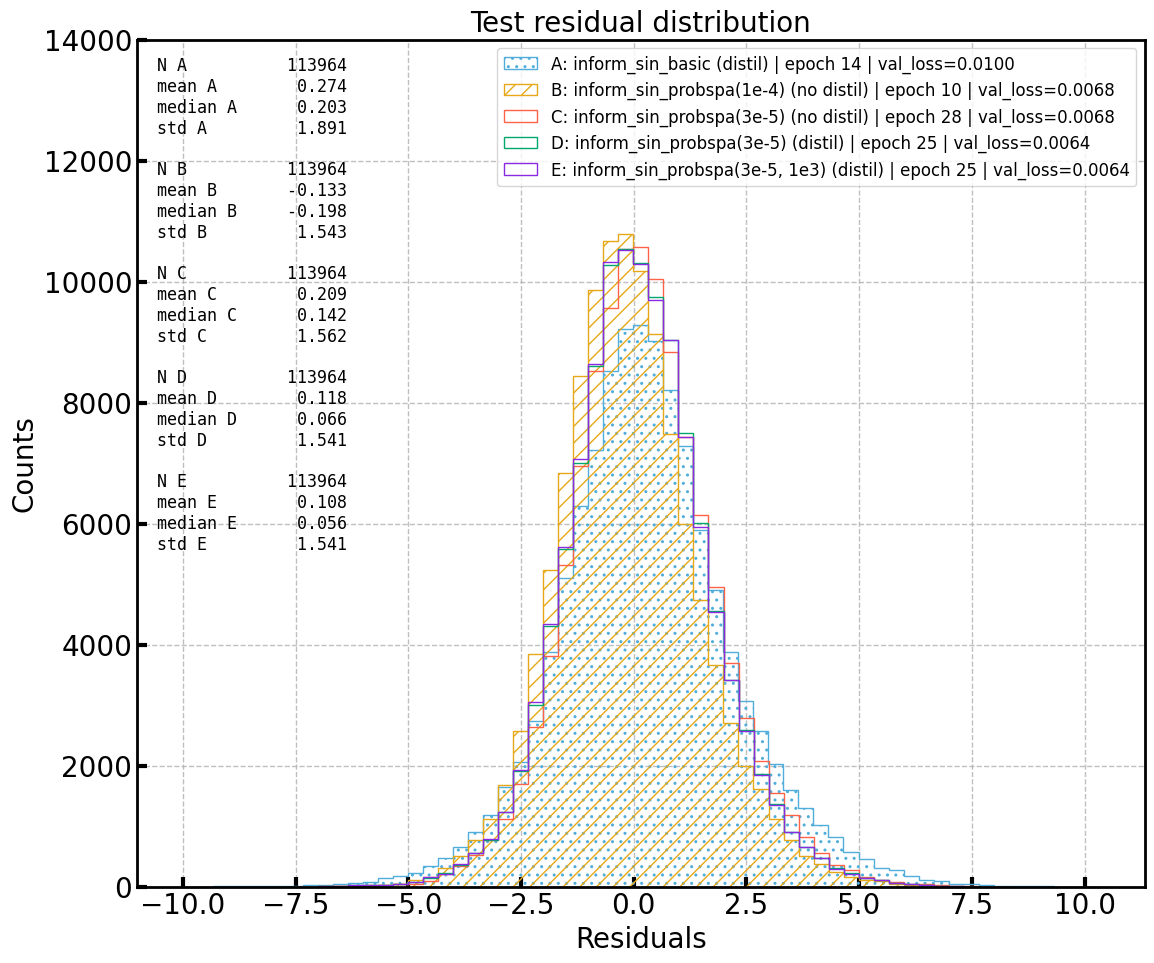

In [53]:
plot_all_residual_distribution(df_informer)

In [54]:
def compute_horizon_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute error metrics grouped by forecast lead time.

    Assumes df contains:
        lead_time, residual, abs_error, squared_error
    """
    horizon_stats = (
        df.groupby("lead_time")
        .agg(
            n_points=("residual", "count"),
            mse=("squared_error", "mean"),
            mae=("abs_error", "mean"),
            bias=("residual", "mean"),
            residual_std=("residual", "std"),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
    )

    horizon_stats["rmse"] = horizon_stats["mse"] ** 0.5

    return horizon_stats

In [55]:
def plot_horizon_metrics(
    df_all: pd.DataFrame,
    metric: str = "rmse",
):
    fig, ax = plt.subplots(figsize=(13, 8))

    grouped = df_all.groupby(
        ["group_id", "run_label", "ckpt_tag", "epoch", "val_loss"],
        dropna=False,
    )

    stat_blocks = []

    for i, ((group_id, run_label, ckpt_tag, epoch, val_loss), df_group) in enumerate(grouped):
        horizon_stats = compute_horizon_metrics(df_group)

        label = f"{group_id}: {make_plot_label(run_label, ckpt_tag, epoch, val_loss)}"

        ax.plot(
            horizon_stats["lead_time"],
            horizon_stats[metric],
            label=label,
            # **getHistStyle(i, filled=False),  # if you made this helper
        )

        d = {
            f"{group_id} mean {metric}": horizon_stats[metric].mean(),
            f"{group_id} max {metric}": horizon_stats[metric].max(),
        }
        stat_blocks.append(nice_string_output(d, decimals=3))

    ax.set_xlabel("Forecast lead time [hour]")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} by forecast horizon")
    ax.legend(fontsize=12)

    add_text_to_ax(
        0.02,
        0.95,
        "\n\n".join(stat_blocks),
        ax,
        fontsize=11,
    )

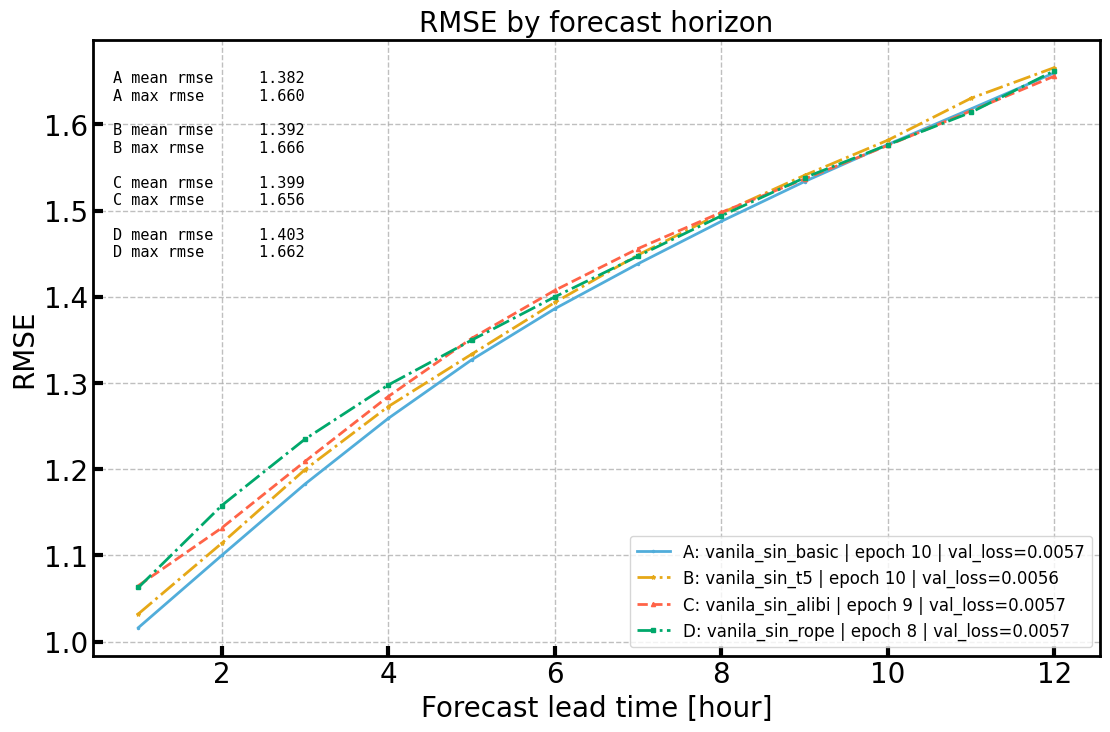

In [56]:
plot_horizon_metrics(df_vanilla)

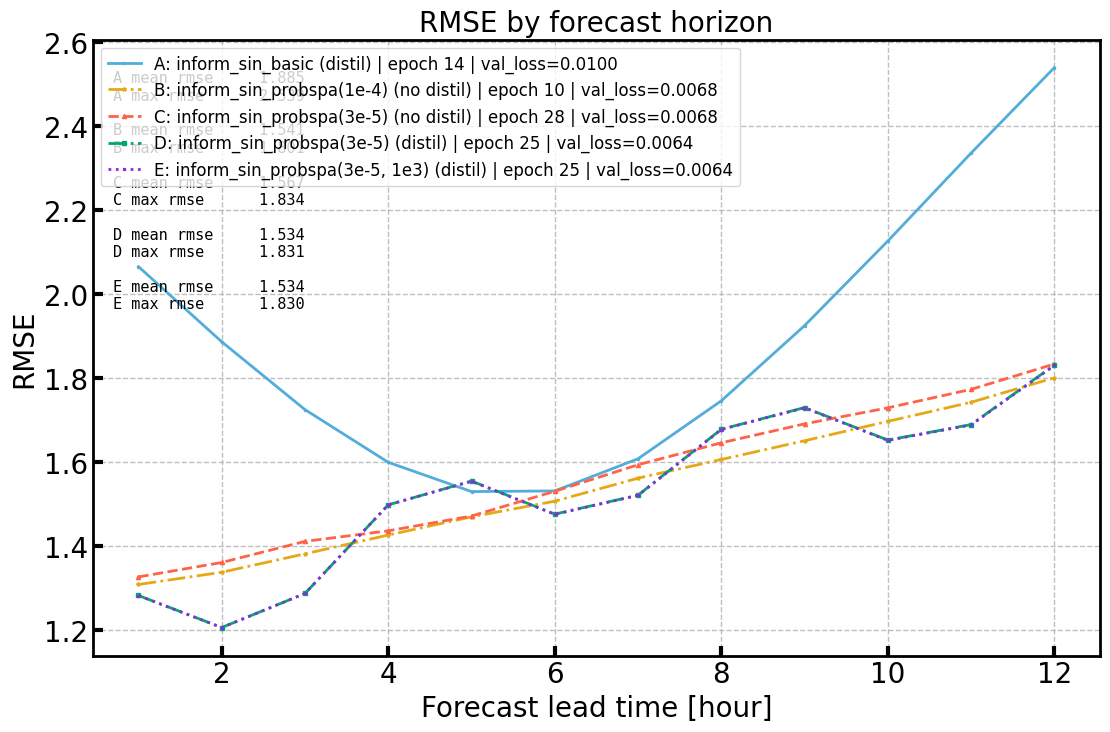

In [57]:
plot_horizon_metrics(df_informer)